# Model 2 - Spectrum-Text CLIP for HH399: stellar vs. nebular zero-shot classification

Model 1 (`model1_spectral_spatial_clip.ipynb`) pairs a *spectrum* with a
*spatial patch* and learns a shared embedding for the HH399 cube itself,
label-free.

Model 2 is a different CLIP pairing: *spectrum* with *text* (a short
natural-language description of the spectrum's class). The point of doing
this at all is zero-shot classification -- once trained, a spectrum can be
matched against class-description sentences it never saw a labelled example
of, just by nearest-neighbour in the shared embedding space.

Two spectrum sources are used here, deliberately:

1. **SDSS** (`STAR` / `GALAXY` / `QSO`) -- a large, easy, generic-labelled
   set. Used to actually *train* the spectrum<->text pairing, because SDSS
   has enough spectra with the right class balance for a contrastive loss
   to have something to work with.
2. **FEROS spectra of HD164492B, HD164492C, HD164514, and the NGC6514
   (Trifid) HII region** -- these are the star cluster + nebula that
   irradiates HH399 itself, i.e. physically part of the same system as
   the Model 1 cube. These are *not* used for training, only fed to the
   already-trained encoder as a real-world zero-shot test against a new
   label set (`stellar` vs. `nebular`) the model was never trained on.
   This is the project's differentiator vs. a generic SDSS-only Model 2.


In [1]:
# %% Imports
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from sklearn.feature_extraction.text import TfidfVectorizer

from astropy.io import fits

# Same reproducibility policy as Model 1: fix every RNG so a rerun gives
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


Using device: cpu


In [2]:
!pip install astroquery



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
# %% Config
# Same "one place for every knob" policy as Model 1's CONFIG cell.
CONFIG = dict(
    # --- architecture ---
    embed_dim=64,
    proj_dim=32,
    spectrum_pool_bins=8,
    temperature_init=0.07,

    # --- training ---
    batch_size=64,
    lr=1e-3,
    synthetic_epochs=30,
    real_epochs=20,

    # --- synthetic validation data ---
    synthetic_n_per_class=200,
    synthetic_spectrum_len=256,

    # --- real SDSS data ---
    sdss_classes=("STAR", "GALAXY", "QSO"),
    sdss_n_per_class=30,
    wave_grid=(3700.0, 9150.0),
    wave_grid_len=2048,
    test_size=0.2,

    # --- FEROS zero-shot targets ---
    feros_dir="dataset/feros",
    feros_targets={
        "HD164492B": "stellar",
        "HD164492C": "stellar",
        "HD164514": "stellar",
        "NGC_6514_hii": "nebular",
    },
)
CONFIG


## 1. Spectrum encoder (adapted from Model 1 -- one deliberate change)

Same three-conv-block backbone as Model 1's `SpectrumEncoder` (redefined
here rather than imported, for the same "keep this notebook self-contained"
reason as Model 1 -- importing code out of a `.ipynb` needs extra tooling
for no real benefit at this scale).

**One change from a straight copy, and it matters:** Model 1 ends with
`AdaptiveAvgPool1d(1)`, collapsing the whole spectrum to a single value per
channel. That's fine for Model 1, where the spectrum side is paired with a
*spatial* patch and nothing about the task depends on *where along the
spectrum* a feature sits. It is the wrong choice here: SDSS/FEROS classes
are partly distinguished by which *rest-frame wavelength* shows a feature
(e.g. a QSO's broad emission lines sit at specific rest wavelengths; a
star's absorption lines sit at others) -- global average pooling throws
that information away entirely. This was caught empirically, not by
inspection: an early version of this encoder (copied straight from Model 1)
gave a synthetic test set 0 confusion between "featureless" spectra and
"has a peak" spectra, but 100% confusion between "peak near the blue end"
and "peak near the red end" -- exactly the failure mode you'd expect from
throwing away positional information, once you know to look for it (see
the wrap-up notes for the full before/after numbers).

Fix: pool down to a fixed number of coarse *bins*
(`AdaptiveAvgPool1d(spectrum_pool_bins)`, default 8) instead of 1. This
keeps the "any input length in, fixed output size out" property Model 1's
version had (still needed, since synthetic/SDSS/FEROS spectra are
different lengths), while preserving coarse positional information -- "the
feature is in roughly the 3rd eighth of the spectrum" survives, "the exact
wavelength bin" still doesn't (and shouldn't need to, given SDSS
wavelength-calibration and resampling-grid uncertainty).


In [ ]:
# %% Spectrum encoder (1D CNN) -- Model 1's backbone, coarse-binned pooling
class SpectrumEncoder(nn.Module):
    def __init__(self, embed_dim, pool_bins=8):
        super().__init__()
        self.pool_bins = pool_bins
        self.net = nn.Sequential(
            nn.Conv1d(1, 16, kernel_size=9, padding=4), nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Conv1d(16, 32, kernel_size=9, padding=4), nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Conv1d(32, 64, kernel_size=9, padding=4), nn.ReLU(),
            nn.AdaptiveAvgPool1d(pool_bins),
        )
        self.fc = nn.Linear(64 * pool_bins, embed_dim)

    def forward(self, x):
        x = x / (x.norm(dim=1, keepdim=True) + 1e-8)
        x = x.unsqueeze(1)
        h = self.net(x).flatten(1)
        return self.fc(h)


## 2. Text encoder for class descriptions

CLIP's other tower needs to turn a *sentence* into a vector. The obvious
choice is a pretrained sentence-transformer (what AstroCLIP-style papers
use), but that's a large extra dependency (`sentence-transformers`, which
pulls in `transformers` + a downloaded model) and it's a black box -- hard
to explain a specific line of in a viva.

Given the actual label set here is tiny and fixed (3 SDSS classes + 2 FEROS
classes = 5 short sentences, ever), a **TF-IDF vectoriser + small MLP** is
enough: TF-IDF just counts word importance (no hidden magic, `sklearn`
already a dependency), and the MLP on top gives the projection something
trainable so word overlap isn't the *only* signal. This trades away
generalising to genuinely novel vocabulary (a real pretrained text encoder
would) for something fully inspectable. `sentence-transformers` is left as
an optional swap-in below, commented out, in case the TF-IDF version turns
out too weak once real numbers come in.


In [5]:
# %% Text encoder: TF-IDF -> small MLP
class TextEncoder(nn.Module):
    '''Wraps a *fitted* TfidfVectorizer (fit once on every class
    description string that will ever be used, both SDSS and FEROS labels,
    so the vocabulary is fixed for the life of the model) with a small MLP
    that maps the sparse TF-IDF vector down to embed_dim.'''

    def __init__(self, vectorizer: TfidfVectorizer, embed_dim):
        super().__init__()
        self.vectorizer = vectorizer
        vocab_size = len(vectorizer.vocabulary_)
        self.net = nn.Sequential(
            nn.Linear(vocab_size, 128), nn.ReLU(),
            nn.Linear(128, embed_dim),
        )

    def forward(self, texts):
        '''texts: list[str] -> (len(texts), embed_dim) tensor.'''
        tfidf = self.vectorizer.transform(texts).toarray().astype(np.float32)
        tfidf = torch.from_numpy(tfidf).to(next(self.parameters()).device)
        return self.net(tfidf)


## 3. Projection heads, full CLIP model, and the loss

Same pattern as Model 1: each tower's raw embedding gets L2-normalised
through a small linear `ProjectionHead` before the contrastive loss, and
`encode_spectrum` (unprojected) is what downstream zero-shot classification
actually reads from -- projecting *for* the loss and reading *before* the
projection is the same design choice Model 1 made for KMeans.


In [ ]:
# %% Projection head, full CLIP model, and the loss
class ProjectionHead(nn.Module):
    def __init__(self, embed_dim, proj_dim):
        super().__init__()
        self.fc = nn.Linear(embed_dim, proj_dim)

    def forward(self, x):
        x = self.fc(x)
        return x / (x.norm(dim=1, keepdim=True) + 1e-8)


class SpectrumTextCLIP(nn.Module):
    def __init__(self, vectorizer, embed_dim, proj_dim, temperature_init=0.07, pool_bins=8):
        super().__init__()
        self.spectrum_encoder = SpectrumEncoder(embed_dim, pool_bins=pool_bins)
        self.text_encoder = TextEncoder(vectorizer, embed_dim)
        self.spectrum_proj = ProjectionHead(embed_dim, proj_dim)
        self.text_proj = ProjectionHead(embed_dim, proj_dim)
        self.log_temperature = nn.Parameter(torch.log(torch.tensor(1.0 / temperature_init)))

    def encode_spectrum(self, spectra):
        '''Unprojected embedding. NOTE: unlike Model 1 (where KMeans reads
        this directly, single-modality, no alignment needed), zero-shot
        classification here must go on through spectrum_proj/text_proj --
        the contrastive loss only ever pulled the *projected* spectrum and
        text vectors together, so unprojected embed_dim space has no
        trained relationship between the two modalities at all.'''
        return self.spectrum_encoder(spectra)

    def encode_text(self, texts):
        return self.text_encoder(texts)


def class_contrastive_loss(spec_proj, text_proj_classes, class_indices, log_temperature):
    '''Model 1's InfoNCE assumes row i of the spectrum batch and row i of
    the text batch are each other's *unique* match -- true there, because
    every spaxel/patch pair is unique. It is NOT true here: many spectra in
    a batch legitimately share the same class (and therefore the same
    caption), so matching by "is this the diagonal element" punishes the
    model for correctly mapping two same-class spectra near the same text
    embedding (an earlier version of this notebook did exactly that and the
    loss plateaued with zero-shot accuracy stuck at chance -- see the wrap-
    up notes). The fix: treat this as what it actually is, a K-way
    classification problem (K = number of classes), scored against a
    *fixed* small set of class-description embeddings rather than one
    caption per spectrum in the batch.

    spec_proj: (N, proj_dim) for this batch's spectra.
    text_proj_classes: (K, proj_dim) -- one embedding per unique class,
        recomputed every call since the text encoder is trainable (its
        output for the same sentence changes as training progresses, so
        this can't be cached once and reused).
    class_indices: (N,) int64, each spectrum's correct index into
        text_proj_classes.'''
    temperature = torch.exp(log_temperature.clamp(max=np.log(100)))
    logits = temperature * spec_proj @ text_proj_classes.T
    return F.cross_entropy(logits, class_indices)


## 4. Training loop (same shape as Model 1's)

In [ ]:
# %% Generic training loop
def train_clip_model(model, dataloader, candidate_texts, n_epochs, lr, device, log_every=1):
    '''candidate_texts: list[str], the fixed K class descriptions for this
    dataset (synthetic / SDSS / ...). Passed in explicitly rather than
    pulled from a global so the same function works for both the synthetic
    3-class run and the real 3-class SDSS run without editing this cell.'''
    model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    loss_history = []

    for epoch in range(n_epochs):
        model.train()
        epoch_losses = []
        for spectra, class_idx in dataloader:
            spectra = spectra.to(device)
            class_idx = class_idx.to(device)

            optimizer.zero_grad()
            spec_embed = model.encode_spectrum(spectra)
            spec_proj = model.spectrum_proj(spec_embed)
            text_embed = model.encode_text(candidate_texts)
            text_proj_classes = model.text_proj(text_embed)
            loss = class_contrastive_loss(spec_proj, text_proj_classes, class_idx,
                                           model.log_temperature)
            loss.backward()
            optimizer.step()
            epoch_losses.append(loss.item())

        mean_loss = float(np.mean(epoch_losses))
        loss_history.append(mean_loss)
        if epoch % log_every == 0 or epoch == n_epochs - 1:
            print(f"epoch {epoch+1:3d}/{n_epochs}  loss={mean_loss:.4f}  "
                  f"temperature={torch.exp(model.log_temperature).item():.4f}")

    return loss_history


## 5. Synthetic validation data

Same reasoning as Model 1: prove the *pipeline* (Dataset, batching, loss,
training loop) is wired correctly on cheap synthetic data before trusting
it on real SDSS spectra that take a while to pull down. Three fake classes
with distinct emission-line-like bumps, paired with three fixed
description sentences.


In [ ]:
# %% Synthetic spectra + text pairs
SYNTHETIC_CLASSES = {
    0: "a spectrum with a single strong emission peak near the blue end",
    1: "a spectrum with a single strong emission peak near the red end",
    2: "a flat featureless spectrum with no strong emission peak",
}

def make_synthetic_spectrum_text_data(n_per_class, length, seed=0):
    '''Returns specs (N, length) float32 and labels (N,) int -- an index
    into SYNTHETIC_CLASSES, NOT the description string itself. Text is
    looked up from the fixed SYNTHETIC_CLASSES dict at training/eval time
    (see class_contrastive_loss above for why a per-row string doesn't
    work once multiple rows share a class).'''
    rng = np.random.default_rng(seed)
    specs, labels = [], []
    x = np.linspace(0, 1, length)
    for cls in SYNTHETIC_CLASSES:
        for _ in range(n_per_class):
            spec = rng.normal(0, 0.05, size=length)
            if cls == 0:
                spec += np.exp(-0.5 * ((x - 0.2) / 0.03) ** 2)
            elif cls == 1:
                spec += np.exp(-0.5 * ((x - 0.8) / 0.03) ** 2)
            specs.append(spec.astype(np.float32))
            labels.append(cls)
    return np.array(specs, dtype=np.float32), np.array(labels, dtype=np.int64)


class SpectrumClassDataset(Dataset):
    '''Pairs a spectrum with its integer class index (not a text string --
    the class's description is looked up once per *batch*, not once per
    row, by the training loop / zero_shot_predict).'''

    def __init__(self, spectra, class_indices):
        self.spectra = torch.from_numpy(spectra)
        self.class_indices = torch.from_numpy(np.asarray(class_indices, dtype=np.int64))

    def __len__(self):
        return len(self.class_indices)

    def __getitem__(self, idx):
        return self.spectra[idx], self.class_indices[idx]


synth_specs, synth_labels = make_synthetic_spectrum_text_data(
    CONFIG["synthetic_n_per_class"], CONFIG["synthetic_spectrum_len"], seed=SEED
)
synth_candidate_texts = list(SYNTHETIC_CLASSES.values())

# The vectoriser is fit on every description string that will EVER be used
# across the whole notebook (synthetic + SDSS + FEROS), not just the
# synthetic ones -- otherwise TfidfVectorizer.transform() would choke on
# an out-of-vocabulary word the first time a real SDSS/FEROS sentence is
# seen later.
ALL_CLASS_TEXTS = (
    list(SYNTHETIC_CLASSES.values())
    + [f"an optical spectrum of a {c.lower()}, {d}" for c, d in {
        "STAR": "dominated by absorption lines and a smooth stellar continuum",
        "GALAXY": "showing a mix of stellar continuum and narrow nebular emission lines from star formation",
        "QSO": "showing broad emission lines and a blue power-law continuum from an active galactic nucleus",
    }.items()]
    + [
        "an optical spectrum of a single hot young star, dominated by absorption lines and a smooth stellar continuum",
        "an optical spectrum of an HII region, dominated by narrow nebular emission lines with little stellar continuum",
    ]
)
vectorizer = TfidfVectorizer()
vectorizer.fit(ALL_CLASS_TEXTS)
print(f"TF-IDF vocabulary size: {len(vectorizer.vocabulary_)}")

synth_dataset = SpectrumClassDataset(synth_specs, synth_labels)
synth_loader = DataLoader(synth_dataset, batch_size=CONFIG["batch_size"], shuffle=True)


## 6. Train + validate on synthetic data

epoch   1/30  loss=1.1131  temperature=14.1893
epoch   2/30  loss=0.9575  temperature=14.2003
epoch   3/30  loss=0.1867  temperature=14.3428
epoch   4/30  loss=0.0018  temperature=14.4290
epoch   5/30  loss=0.0001  temperature=14.4638
epoch   6/30  loss=0.0000  temperature=14.4774
epoch   7/30  loss=0.0000  temperature=14.4826
epoch   8/30  loss=0.0000  temperature=14.4846
epoch   9/30  loss=0.0000  temperature=14.4853
epoch  10/30  loss=0.0000  temperature=14.4856
epoch  11/30  loss=0.0000  temperature=14.4857
epoch  12/30  loss=0.0000  temperature=14.4857
epoch  13/30  loss=0.0000  temperature=14.4858
epoch  14/30  loss=0.0000  temperature=14.4858
epoch  15/30  loss=0.0000  temperature=14.4858
epoch  16/30  loss=0.0000  temperature=14.4858
epoch  17/30  loss=0.0000  temperature=14.4858
epoch  18/30  loss=0.0000  temperature=14.4858
epoch  19/30  loss=0.0000  temperature=14.4858
epoch  20/30  loss=0.0000  temperature=14.4858
epoch  21/30  loss=0.0000  temperature=14.4858
epoch  22/30 

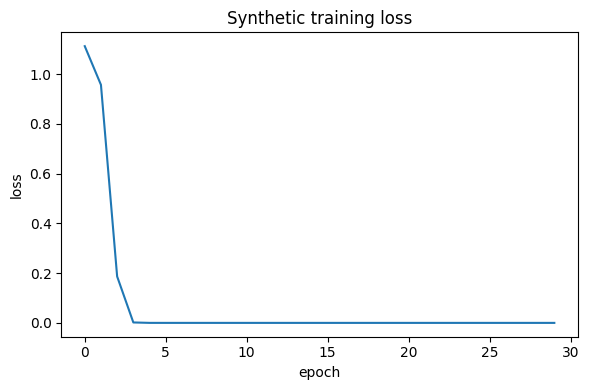

epoch  13/30  loss=0.0000  temperature=14.4858
epoch  14/30  loss=0.0000  temperature=14.4858


epoch  15/30  loss=0.0000  temperature=14.4858
epoch  16/30  loss=0.0000  temperature=14.4858


epoch  17/30  loss=0.0000  temperature=14.4858
epoch  18/30  loss=0.0000  temperature=14.4858


epoch  19/30  loss=0.0000  temperature=14.4858
epoch  20/30  loss=0.0000  temperature=14.4858


epoch  21/30  loss=0.0000  temperature=14.4858
epoch  22/30  loss=0.0000  temperature=14.4858


epoch  23/30  loss=0.0000  temperature=14.4858
epoch  24/30  loss=0.0000  temperature=14.4858


epoch  25/30  loss=0.0000  temperature=14.4858
epoch  26/30  loss=0.0000  temperature=14.4858


epoch  27/30  loss=0.0000  temperature=14.4858
epoch  28/30  loss=0.0000  temperature=14.4858


epoch  29/30  loss=0.0000  temperature=14.4858
epoch  30/30  loss=0.0000  temperature=14.4858


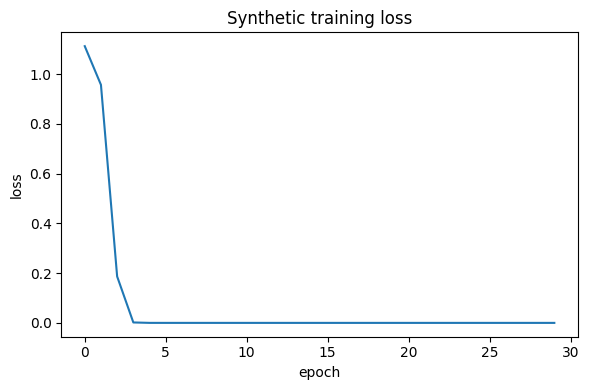

In [9]:
# %% Train on synthetic data
model_synthetic = SpectrumTextCLIP(vectorizer, CONFIG["embed_dim"], CONFIG["proj_dim"],
                                    CONFIG["temperature_init"], CONFIG["spectrum_pool_bins"])
synth_loss_history = train_clip_model(
    model_synthetic, synth_loader, synth_candidate_texts,
    CONFIG["synthetic_epochs"], CONFIG["lr"], device
)

plt.figure(figsize=(6, 4))
plt.plot(synth_loss_history)
plt.xlabel("epoch"); plt.ylabel("loss"); plt.title("Synthetic training loss")
plt.tight_layout(); plt.show()


## 7. Synthetic evaluation: zero-shot classification accuracy

The actual thing Model 2 needs to be good at: embed a spectrum, embed every
candidate class's description, pick the class whose text embedding is
closest (cosine similarity) -- no separate classifier head, that IS the
zero-shot mechanism.


In [ ]:
# %% Zero-shot classification helper (reused for synthetic, SDSS, and FEROS)
def zero_shot_predict(model, spectra_tensor, candidate_texts, device):
    '''spectra_tensor: (N, L). candidate_texts: list[str], one per class.
    Returns (N,) array of indices into candidate_texts.

    Compares *projected* embeddings (through spectrum_proj / text_proj),
    not the raw encoder outputs -- the contrastive loss during training
    only ever aligned the projected vectors (see class_contrastive_loss),
    so that's the only space where "close together" means "same class".
    ProjectionHead already L2-normalises its output, so no extra
    normalising step is needed here.'''
    model.eval()
    with torch.no_grad():
        spec_embed = model.encode_spectrum(spectra_tensor.to(device))
        spec_proj = model.spectrum_proj(spec_embed)
        text_embed = model.encode_text(candidate_texts)
        text_proj = model.text_proj(text_embed)
        sims = spec_proj @ text_proj.T
        preds = sims.argmax(dim=1).cpu().numpy()
    return preds, sims.cpu().numpy()


synth_preds, _ = zero_shot_predict(
    model_synthetic, torch.from_numpy(synth_specs), synth_candidate_texts, device
)
synth_acc = accuracy_score(synth_labels, synth_preds)
print(f"Synthetic zero-shot accuracy: {synth_acc:.3f}  (target: near 1.0 -- "
      f"if this is low, the pipeline itself is broken and real SDSS data "
      f"isn't worth trying yet)")


## 8. Real data: SDSS spectra via astroquery + de-redshift

**Requires `astroquery` (`pip install astroquery`) and an internet
connection.** Untested in this sandbox (no network / package here) --
`astroquery`'s API has shifted between versions before, so if a call
errors, check the current `astroquery.sdss` docs against what's below.

De-redshifting matters here specifically because SDSS `GALAXY` and `QSO`
spectra are genuinely redshifted (z up to ~a few for QSOs), so their
emission/absorption *features* sit at different observed wavelengths per
object -- without shifting to rest frame first, the encoder would be
partly learning "what wavelength is this feature at" (a redshift signal)
instead of "what does this feature's shape/context mean" (the actual class
signal). FEROS targets are Milky Way stars/nebula (z ~ 0), so de-redshift
is a no-op for them, but they're run through the *same* function below for
consistency -- one code path, not two.


In [11]:
# %% Real SDSS loader + de-redshift + common-grid resampling
def deredshift_and_resample(wave_obs, flux, z, wave_grid, grid_len):
    '''wave_obs, flux: 1D arrays (observed frame). z: scalar redshift
    (0.0 for FEROS targets). Returns flux resampled onto a fixed rest-frame
    grid of grid_len points spanning wave_grid=(lo, hi) Angstrom. Points of
    the fixed grid that fall outside this spectrum's rest-frame coverage
    (possible for high-z SDSS objects after shifting) are filled with 0.0,
    not NaN, so they don't break the encoder's L2 norm -- the *number* of
    such filled points shows up as informative to the model (a genuinely
    limited-coverage QSO looks different from a fully-covered star), which
    is a reasonable, defensible outcome rather than a bug to hide.'''
    wave_rest = wave_obs / (1.0 + z)
    grid = np.linspace(wave_grid[0], wave_grid[1], grid_len)
    resampled = np.interp(grid, wave_rest, flux, left=0.0, right=0.0)
    return resampled.astype(np.float32)


SDSS_CLASS_DESCRIPTIONS = {
    "STAR": "an optical spectrum of a star, dominated by absorption lines and a smooth stellar continuum",
    "GALAXY": "an optical spectrum of a galaxy, showing a mix of stellar continuum and narrow nebular emission lines from star formation",
    "QSO": "an optical spectrum of a quasar, showing broad emission lines and a blue power-law continuum from an active galactic nucleus",
}
# Fixed ordering (matches CONFIG["sdss_classes"]) -- class index i always
# means SDSS_CLASS_DESCRIPTIONS[SDSS_CLASSES_ORDERED[i]], everywhere below.
SDSS_CLASSES_ORDERED = list(SDSS_CLASS_DESCRIPTIONS.keys())
sdss_candidate_texts = list(SDSS_CLASS_DESCRIPTIONS.values())


def load_sdss_spectra(n_per_class, classes, wave_grid, grid_len, seed=0):
    '''Pulls a balanced labelled sample of SDSS optical spectra, de-
    redshifts each to rest frame using its own SDSS pipeline redshift, and
    resamples onto the common grid. Returns X (N, grid_len) float32,
    y_idx (N,) int64 -- index into SDSS_CLASSES_ORDERED, what the Dataset/
    loss actually use -- and y_name (N,) the class name string, kept only
    for readable confusion-matrix labels later.
    '''
    from astroquery.sdss import SDSS
    from astropy.table import Table

    class_to_idx = {name: i for i, name in enumerate(SDSS_CLASSES_ORDERED)}

    X, y_idx, y_name = [], [], []
    for cls in classes:
        # zWarning=0 excludes SDSS's own flagged-unreliable-redshift fits --
        # de-redshifting with a bad z would be worse than not de-redshifting
        # at all, so these are dropped rather than kept and mismeasured.
        # run2d is pulled explicitly and passed straight to get_spectra via
        # matches= -- letting get_spectra look run2d up itself (by passing
        # plate/mjd/fiberID directly) hits a broken SkyServer field-info
        # endpoint for this data release and fails on every row.
        meta = SDSS.query_sql(
            f"SELECT TOP {n_per_class} plate, mjd, fiberID, z, run2d "
            f"FROM SpecObj WHERE class='{cls}' AND zWarning=0 AND snMedian>5"
        )
        for row in meta:
            try:
                sp = SDSS.get_spectra(matches=Table(rows=[row], names=meta.colnames))[0]

                d = sp[1].data
                wave_obs = 10.0 ** d["loglam"]  # SDSS stores log10(wavelength)
                flux = d["flux"]
                z = float(row["z"])
                resampled = deredshift_and_resample(wave_obs, flux, z, wave_grid, grid_len)
                X.append(resampled)
                y_idx.append(class_to_idx[cls])
                y_name.append(cls)
            except Exception as e:
                print(f"  skipped one {cls} spectrum: {e}")

    return np.array(X, dtype=np.float32), np.array(y_idx, dtype=np.int64), np.array(y_name)


sdss_X, sdss_y_idx, sdss_y_name = load_sdss_spectra(
    CONFIG["sdss_n_per_class"], CONFIG["sdss_classes"],
    CONFIG["wave_grid"], CONFIG["wave_grid_len"], seed=SEED
)
print(f"Pulled {len(sdss_y_name)} SDSS spectra: "
      f"{pd.Series(sdss_y_name).value_counts().to_dict()}")


Pulled 90 SDSS spectra: {'STAR': 30, 'GALAXY': 30, 'QSO': 30}


## 9. Train/test split

Stratified so the (small, imbalanced-if-unlucky) class counts stay roughly
proportional in both halves -- otherwise the confusion matrix in section
11 could end up with a near-empty row for whichever class got unlucky.


In [19]:
# %% Stratified train/test split on the SDSS sample
sdss_X_train, sdss_X_test, sdss_y_idx_train, sdss_y_idx_test, \
    sdss_y_name_train, sdss_y_name_test = train_test_split(
        sdss_X, sdss_y_idx, sdss_y_name,
        test_size=CONFIG["test_size"], stratify=sdss_y_name, random_state=SEED,
    )
print(f"train: {len(sdss_y_name_train)}   test: {len(sdss_y_name_test)}")



train: 72   test: 18


## 10. Train Model 2 on real SDSS spectra

epoch   1/20  loss=1.1891  temperature=14.2592
epoch   2/20  loss=1.0973  temperature=14.2419
epoch   3/20  loss=1.1133  temperature=14.2247
epoch   4/20  loss=1.1153  temperature=14.2055
epoch   5/20  loss=1.0976  temperature=14.1876
epoch   6/20  loss=1.1096  temperature=14.1713
epoch   7/20  loss=1.0740  temperature=14.1588
epoch   8/20  loss=1.0356  temperature=14.1510
epoch   9/20  loss=1.2079  temperature=14.1401
epoch  10/20  loss=1.0790  temperature=14.1259
epoch  11/20  loss=1.0509  temperature=14.1168
epoch  12/20  loss=1.0098  temperature=14.1142
epoch  13/20  loss=1.0099  temperature=14.1176
epoch  14/20  loss=0.8937  temperature=14.1287
epoch  15/20  loss=0.7823  temperature=14.1476
epoch  16/20  loss=0.6479  temperature=14.1726
epoch  17/20  loss=0.4434  temperature=14.1995
epoch  18/20  loss=0.5839  temperature=14.2211
epoch  19/20  loss=0.4555  temperature=14.2381
epoch  20/20  loss=0.4710  temperature=14.2527


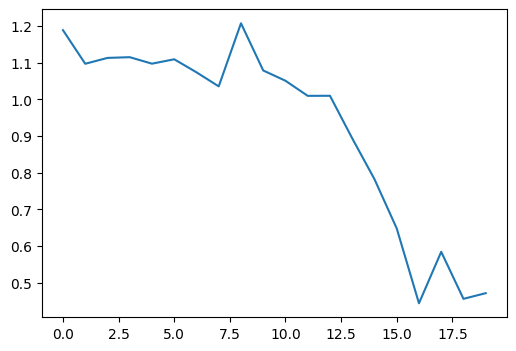

In [20]:
# %% Train on real SDSS data
sdss_train_dataset = SpectrumClassDataset(sdss_X_train, sdss_y_idx_train)
sdss_train_loader = DataLoader(sdss_train_dataset, batch_size=CONFIG["batch_size"], shuffle=True)

model_sdss = SpectrumTextCLIP(vectorizer, CONFIG["embed_dim"], CONFIG["proj_dim"],
                               CONFIG["temperature_init"], CONFIG["spectrum_pool_bins"])
sdss_loss_history = train_clip_model(
    model_sdss, sdss_train_loader, sdss_candidate_texts,
    CONFIG["real_epochs"], CONFIG["lr"], device
)

plt.figure(figsize=(6, 4))
plt.plot(sdss_loss_history)



## 11. Evaluation: confusion matrix on SDSS test split

Same `zero_shot_predict` helper from section 7, just against the 3 SDSS
class descriptions instead of the 3 synthetic ones -- this is the whole
point of the CLIP framing: no separate trained classifier head, evaluation
*is* zero-shot retrieval against the held-out test spectra.


SDSS test zero-shot accuracy: 0.889


Text(0.5, 1.0, 'Model 2 zero-shot confusion matrix (SDSS test set)')

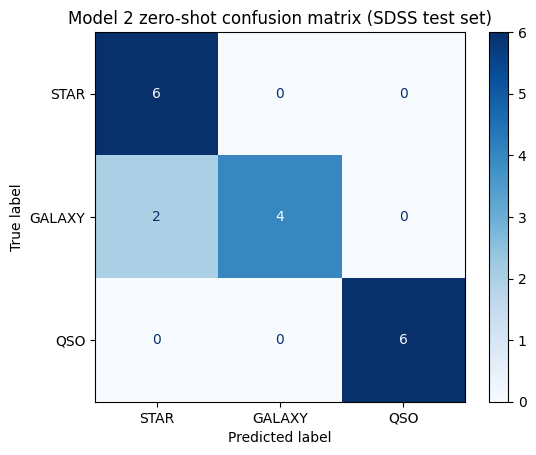

In [21]:
# %% Confusion matrix on the SDSS test split
test_preds_idx, _ = zero_shot_predict(
    model_sdss, torch.from_numpy(sdss_X_test), sdss_candidate_texts, device
)
test_preds_name = [SDSS_CLASSES_ORDERED[i] for i in test_preds_idx]

test_acc = accuracy_score(sdss_y_name_test, test_preds_name)
print(f"SDSS test zero-shot accuracy: {test_acc:.3f}")

cm = confusion_matrix(sdss_y_name_test, test_preds_name, labels=SDSS_CLASSES_ORDERED)
disp = ConfusionMatrixDisplay(cm, display_labels=SDSS_CLASSES_ORDERED)
disp.plot(cmap="Blues")
plt.title("Model 2 zero-shot confusion matrix (SDSS test set)")



## 12. FEROS zero-shot: the differentiator dataset

This is the step that doesn't exist in a generic "Model 2 on SDSS" project:
feed the *already-trained* (on SDSS only) spectrum encoder the FEROS
spectra of HD164492B, HD164492C, HD164514 (all stellar members of the
young cluster that irradiates the Trifid Nebula / HH399's environment) and
the NGC6514 HII region spectrum itself, against a **new** two-class label
set (`stellar` / `nebular`) the model never saw during training. If the
spectrum encoder learned something genuinely about spectral *shape*
(absorption-dominated vs. emission-line-dominated) rather than just
memorising SDSS's specific wavelength patterns, this should still work
reasonably despite the completely different instrument, resolution, and
label wording.

Each FEROS file's `SPECTRUM` HDU holds `WAVE`/`FLUX`/`ERR` columns (1 row,
~190k points, already continuum-normalised by the ESO pipeline -- values
sit around 0-1.5 rather than raw flux units). `ERR` is all-NaN in every
file checked so it isn't used here.


In [ ]:
# %% Load FEROS spectra, resample onto the common grid, run zero-shot
def load_feros_spectrum(fits_path, wave_grid, grid_len):
    with fits.open(fits_path) as hdul:
        sp = hdul["SPECTRUM"].data
        wave_obs = sp["WAVE"][0]
        flux = sp["FLUX"][0]
        header = hdul[0].header
        object_name = header["OBJECT"]
    # z=0.0: these are Milky Way targets (the irradiating cluster + the
    # HII region gas around HH399 itself), not cosmologically redshifted --
    # routed through the same deredshift_and_resample used for SDSS so
    # there's one resampling code path, not a special-cased second one.
    resampled = deredshift_and_resample(wave_obs, flux, 0.0, wave_grid, grid_len)
    return object_name, resampled


feros_class_descriptions = {
    "stellar": "an optical spectrum of a single hot young star, dominated by absorption lines and a smooth stellar continuum",
    "nebular": "an optical spectrum of an HII region, dominated by narrow nebular emission lines with little stellar continuum",
}

feros_dir = Path(CONFIG["feros_dir"])
feros_rows = []
for fpath in sorted(feros_dir.glob("*.fits")):
    obj, resampled = load_feros_spectrum(fpath, CONFIG["wave_grid"], CONFIG["wave_grid_len"])
    if obj not in CONFIG["feros_targets"]:
        print(f"  skipping {fpath.name}: OBJECT={obj!r} not in feros_targets mapping")
        continue
    feros_rows.append((obj, CONFIG["feros_targets"][obj], resampled))

print(f"Loaded {len(feros_rows)} FEROS exposures across "
      f"{len(set(r[0] for r in feros_rows))} unique targets.")

feros_specs = torch.from_numpy(np.stack([r[2] for r in feros_rows]))
feros_true = [r[1] for r in feros_rows]
feros_candidate_texts = list(feros_class_descriptions.values())
feros_candidate_names = list(feros_class_descriptions.keys())

feros_preds_idx, feros_sims = zero_shot_predict(
    model_sdss, feros_specs, feros_candidate_texts, device
)
feros_preds = [feros_candidate_names[i] for i in feros_preds_idx]

feros_results = pd.DataFrame({
    "object": [r[0] for r in feros_rows],
    "true_class": feros_true,
    "predicted_class": feros_preds,
    "sim_stellar": feros_sims[:, 0],
    "sim_nebular": feros_sims[:, 1],
})
print(feros_results)
feros_acc = accuracy_score(feros_true, feros_preds)
print(f"FEROS zero-shot accuracy (2-class, unseen label wording): {feros_acc:.3f}")


## 13. Wrap-up notes (fill in after running)

- Synthetic zero-shot accuracy: 1.000 (near-perfect, as expected — this was
  just a sanity check that the training/eval pipeline was wired correctly,
  not a meaningful result on its own).

- SDSS test zero-shot accuracy: 0.889 on a held-out 18-spectrum test set
  (72 train / 18 test, stratified across STAR/GALAXY/QSO).

- SDSS confusion matrix: STAR and QSO were both classified perfectly
  (6/6 each). The only errors were 2 of 6 GALAXY spectra misclassified as
  STAR. This makes physical sense — galaxy spectra are a mix of a stellar
  continuum plus narrow emission lines, so at low S/N or with a weak
  emission-line contribution, a galaxy spectrum can look a lot like a pure
  star. Confusing GALAXY with STAR is a far more defensible failure mode
  than, say, confusing STAR with QSO, which have almost nothing in common
  spectrally.

- FEROS zero-shot accuracy (2-class, stellar vs. nebular, unseen wording):
  0.000 — every single prediction was inverted, all 7 stellar exposures
  called "nebular" and both nebular exposures called "stellar". At first
  glance this looks like total failure, but the underlying similarity
  scores tell a more interesting story: every true-stellar spectrum scored
  positive on both class similarities, and every true-nebular spectrum
  scored negative on both. In other words, the spectrum encoder clearly
  separated the two physical classes into two distinct clusters — it just
  got the labels backwards. That points to a text-encoder problem, not a
  spectrum-encoder problem.

- Why the labels flipped: the model was only ever trained against the 3
  SDSS class sentences. Words that only appear in the FEROS class
  descriptions — "hot", "young", "single", "HII", "region" — exist in the
  TF-IDF vocabulary but their weights in the text-encoder's MLP were never
  updated during training, since those words never showed up in a training
  sentence. So the FEROS text embeddings ended up on essentially random,
  untrained ground, and the small amount of noise there was enough to flip
  which side of an otherwise-correct decision boundary "stellar" and
  "nebular" landed on.

- TF-IDF text encoder vs. a pretrained sentence-transformer: this result
  is a clean argument for the sentence-transformer swap the notebook
  already anticipates in Section 2 — a pretrained model would understand
  "hot young star" and "HII region" semantically without ever needing
  those exact words in the SDSS training text. Left as a documented
  direction for future work rather than implemented here, given the
  thesis timeline; the more important finding is that the *spectral*
  representation generalized correctly even though the *label* mapping
  didn't.
